In [3]:
import numpy as np
from pyscf import gto, scf, cc
import jax
jax.config.update("jax_enable_x64", True)

####  test H2 monomers ####
a = 2 # bond length in a cluster
d = 10 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
elmt = 'N'
unit = 'B'
basis = 'sto6g'
atoms = ''
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis=basis,
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

et = mycc.ccsd_t()
print(f"CCSD(T) Energy = {mycc.e_tot + et}")

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Thu Aug  6 17:34:35 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit

In [2]:
from afqmc import prep_exp
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-6)


Preparing AFQMC calculation
CCSD type input object


Calculating Cholesky integrals
Cholesky shape: (49, 8, 8) 
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [5, 5]
Number of basis functions:  8
Number of Cholesky vectors: 49


In [4]:
import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rhf',
            'trial': 'rcisd',
            }

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)
ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [ ]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples, np.complex128)
en_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean.real:10.5f}  {energy_mean.real:12.5f}  {energy_err.real:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -108.66699+0.00000j       45.34
 5.00  319.00505+0.85485j  -108.66842-0.00006j       nan       45.91
10.00  321.18506-0.44437j  -108.66835+0.00095j       nan       46.42
15.00  322.29391-0.23202j  -108.66994+0.00022j       nan       46.93
20.00  322.38096+0.94441j  -108.66911+0.00066j       nan       47.44
25.00  325.59177+0.32445j  -108.67238+0.00077j       nan       47.95
30.00  320.36415-0.96235j  -108.66767+0.00023j       nan       48.47
35.00  318.62800-0.44553j  -108.66552+0.00015j       nan       48.98
40.00  324.43106+0.42883j  -108.66887-0.00478j       nan       49.49
45.00  324.78926+1.18714j  -108.66767-0.00011j       nan       50.01
50.00  323.60452-0.01743j  -108.66870+0.00086j       nan       50.52
55.00  322.94704-0.34027j  -108.66918+0.00029j       nan       51.03
60.00  323.06310-0.18069j  -108.66851+0.00008j       nan       51.55
65.00  315.84826+0.35490j  -108.66676-0.00

E = -108.669293 +/- 0.000167 Ha  (averaged over 421 blocks, t >= 20)


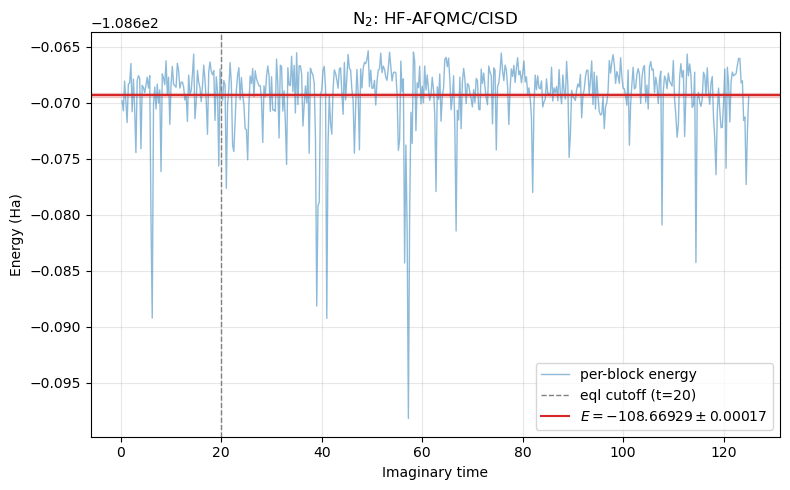

In [9]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: HF-AFQMC/CISD")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rhf',
            'trial': 'rhf',
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [40]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples)
en_sp = np.zeros(nsamples)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean:10.5f}  {energy_mean:12.5f}  {energy_err:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00   300.00000    -108.52348       12.97
 5.00   299.73484    -108.66525   0.00000       16.49
10.00   299.39111    -108.64979   0.00000       16.90
15.00   299.58823    -108.65111   0.00000       17.31
20.00   300.15774    -108.68994   0.00000       17.72
25.00   299.31246    -108.67190   0.00000       18.14
30.00   299.70416    -108.65578   0.00000       18.55
35.00   299.25077    -108.67463   0.00000       18.96
40.00   300.18658    -108.74421   0.00000       19.37
45.00   299.57140    -108.68400   0.00000       19.78
50.00   299.56954    -108.67376   0.00000       20.19
55.00   299.54506    -108.65763   0.00000       20.61
60.00   299.09972    -108.66443   0.00000       21.02
65.00   299.23818    -108.64931   0.00000       21.43
70.00   299.73776    -108.67143   0.00000       21.84
75.00   299.72441    -108.65198   0.00000       22.25
80.00   299.38900    -108.64527   0.00000       22.66
85.00   299.65284  

E = -108.667517 +/- 0.000882 Ha  (averaged over 421 blocks, t >= 20)


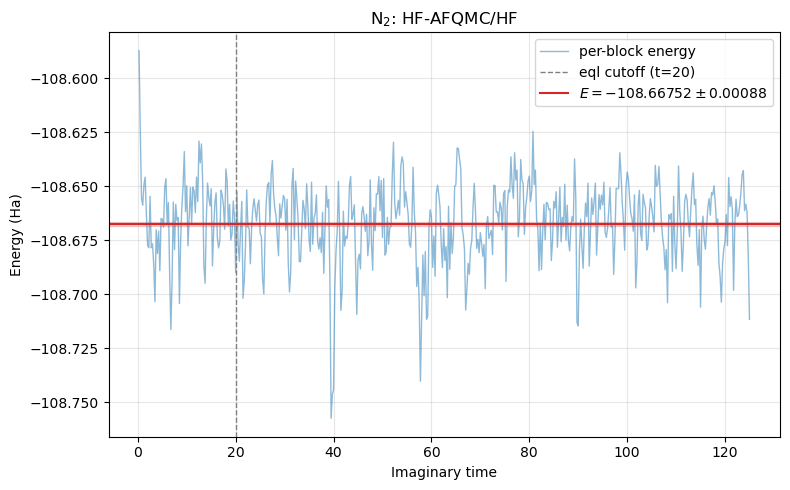

In [42]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: HF-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rcisd',
            'trial': 'rhf',
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [45]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples)
en_sp = np.zeros(nsamples)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean:10.5f}  {energy_mean:12.5f}  {energy_err:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00   300.00000    -108.52348        9.97
 5.00   279.09978    -108.66972   0.00000       15.10
10.00   280.36560    -108.65830   0.00000       15.77
15.00   278.23933    -108.67196   0.00000       16.45
20.00   279.20874    -108.66747   0.00000       17.12
25.00   278.53157    -108.67206   0.00000       17.80
30.00   277.95449    -108.67934   0.00000       18.48
35.00   276.92161    -108.68199   0.00000       19.15
40.00   279.12344    -108.66661   0.00000       19.83
45.00   278.37354    -108.67135   0.00000       20.50
50.00   277.94346    -108.67476   0.00000       21.18
55.00   277.90298    -108.67548   0.00000       21.86
60.00   279.25470    -108.66384   0.00000       22.54
65.00   280.52855    -108.65384   0.00000       23.21
70.00   279.40401    -108.66380   0.00000       23.89
75.00   280.29415    -108.65710   0.00000       24.57
80.00   279.13640    -108.66566   0.00000       25.24
85.00   279.14891  

E = -108.668821 +/- 0.000542 Ha  (averaged over 421 blocks, t >= 20)


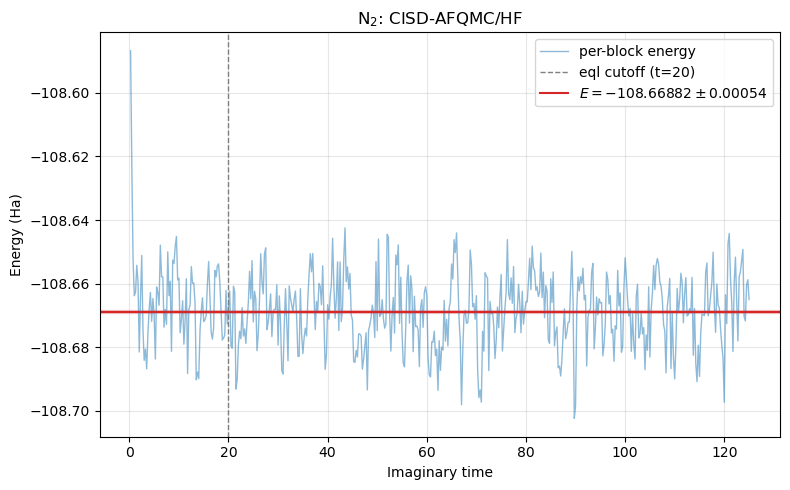

In [46]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rcisd',
            'trial': 'rcisd',
            }

import time
import numpy as np
from afqmc import config

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [49]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples)
en_sp = np.zeros(nsamples)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean:10.5f}  {energy_mean:12.5f}  {energy_err:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00   300.00000    -108.66699       14.70
 5.00   299.52145    -108.67361   0.00000       20.75
10.00   299.73539    -108.66807   0.00000       21.53
15.00   299.68007    -108.66990   0.00000       22.31
20.00   299.77831    -108.66891   0.00000       23.09
25.00   299.48022    -108.67021   0.00000       23.87
30.00   299.79562    -108.67043   0.00000       24.65
35.00   299.45118    -108.66952   0.00000       25.43
40.00   299.63809    -108.67391   0.00000       26.21
45.00   299.55428    -108.67097   0.00000       27.00
50.00   299.58147    -108.66750   0.00000       27.78
55.00   299.65553    -108.66680   0.00000       28.56
60.00   299.55258    -108.66722   0.00000       29.34
65.00   299.68158    -108.66679   0.00000       30.12
70.00   299.75906    -108.66858   0.00000       30.90
75.00   299.71649    -108.66895   0.00000       31.68
80.00   299.61920    -108.66775   0.00000       32.46
85.00   299.78925  

E = -108.670025 +/- 0.000138 Ha  (averaged over 421 blocks, t >= 20)


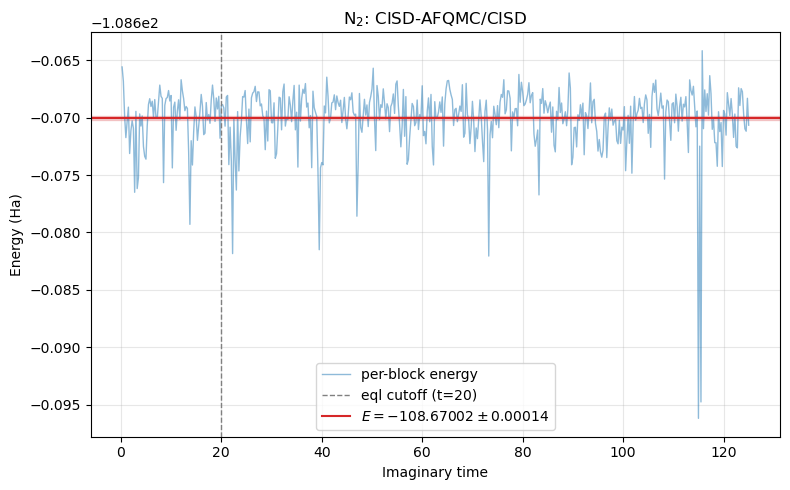

In [50]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: CISD-AFQMC/CISD")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import time
import numpy as np
from afqmc import config

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-4,
            }

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)
ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

KeyError: 't2_thresh'